In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle
from astropy.visualization import ZScaleInterval
from astropy.table import Table
from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack
from scipy.optimize import curve_fit
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors
import fsps
import sedpy
import prospect
import emcee
import dynesty


# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

pf.housestyle_rcparams()
rest_lambdas = {
# --- Primary [OIII] and [OII] ---
'oiii5007': 5006.84,
'oiii4959': 4958.91,
'oii3726':  3726.03,
'oii3729':  3728.82,

# --- Hydrogen Balmer Series ---
'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,

# --- Key Diagnostic Lines ---
'oiii4363': 4363.21,
'neiii':    3868.75,

# --- Low-Ionization Lines ---
'nii6583':  6583.45,
'nii6548':  6548.05,
'sii6716':  6716.44,
'sii6731':  6730.82,

# --- Helium Lines ---
'heii4686': 4685.68,
'hei5876':  5875.62,
}
balmer_lambda = {
# 'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,
}
lambda_keys = {
# --- Primary [OIII] and [OII] ---
'oiii5007': r'[OIII] $\lambda$5007',
'oiii4959': r'[OIII] $\lambda$4959',
'oii3726':  r'[OII] $\lambda$3726',
'oii3729':  r'[OII] $\lambda$3729',

# --- Hydrogen Balmer Series ---
'halpha':   r'H$\alpha$',
'hbeta':    r'H$\beta$',
'hgamma':   r'H$\gamma$',
'hdelta':   r'H$\delta$',
'hepsilon': r'H$\epsilon$',
'hzeta':    r'H$\zeta$',
'heta':     r'H$\eta$',

# --- Key Diagnostic Lines ---
'oiii4363': r'[OIII] $\lambda$4363',  # Auroral line
'neiii':    r'[NeIII] $\lambda$3869',

# --- Low-Ionization Lines ---
'nii6583':  r'[NII] $\lambda$6583',
'nii6548':  r'[NII] $\lambda$6548',
'sii6716':  r'[SII] $\lambda$6716',
'sii6731':  r'[SII] $\lambda$6731',

# --- Helium Lines (not forbidden) ---
'heii4686': r'HeII $\lambda$4686',
'hei5876':  r'HeI $\lambda$5876',
}
from glob import glob

In [2]:
tab = ascii.read('test_for_sed.csv')
candidate = tab[0]


## find file ##
name  = candidate['name']
allfiles = glob('/Volumes/Expansion/exp_thardy/cubes/*.fits')+glob('/Volumes/Expansion/exp_thardy/cubes_new/*.fits')
filedir = 'BLANK'
for a in allfiles:
    if name in a:
        filedir = a
    
coord = SkyCoord(ra=candidate['ra'], dec=candidate['dec'], unit=u.deg)
cube = Cube(filedir)
spectrum = cube.aperture((coord.dec.deg,coord.ra.deg),2)

In [24]:
spectrum = spectrum.resample(2.5)
conv_factor = (1.0 / speedoflight).to(u.Jy * u.s * u.cm**2 / (u.erg *u.AA))
flux_lambda = spectrum.data.data*u.erg/(u.AA*u.s*u.cm**2)*1e-20
wavelength = spectrum.wave.coord()*u.AA
flux_jansky = conv_factor * flux_lambda * wavelength**2
flux_maggie = flux_jansky/3631

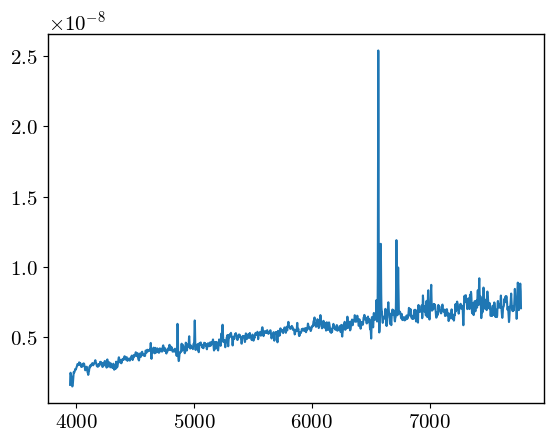